# Dimensionality Reduction with PCA: Digit Recognition 
**Dataset:** MNIST / Digit Recognizer (`train.csv`)  
**Goal:** Demonstrate how Principal Component Analysis (PCA) can combat the "Curse of Dimensionality" in image classification. We will use K-Nearest Neighbors (KNN) as our baseline model and visualize the high-dimensional image data in 2D and 3D space.

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv('train.csv')

In [3]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
20948,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


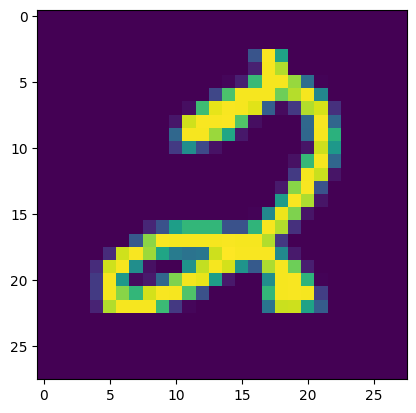

In [5]:
plt.imshow(df.iloc[1780, 1:].values.reshape(28, 28))

In [6]:
X=df.iloc[:, 1:]
y=df.iloc[:, 0]

## 1. The Baseline Model (Without PCA)
First, we establish a baseline using standard K-Nearest Neighbors (KNN). 
Images are inherently high-dimensional. A 28x28 pixel image represents **784 distinct features** (columns). KNN struggles in high-dimensional spaces (the "Curse of Dimensionality") because the distance between all points starts to look exactly the same, making it slow and sometimes less accurate due to background noise.

In [7]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
X_train.shape

(33600, 784)

In [9]:
knn_base=KNeighborsClassifier()

In [10]:
knn_base.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [11]:
y_pred_base=knn_base.predict(X_test)

In [12]:
accuracy_score(y_test, y_pred_base)

0.9648809523809524

## 2. Feature Scaling & PCA Transition
**Crucial Step:** PCA is highly sensitive to the scale of the features. Because it maximizes variance, features with naturally larger ranges will dominate the principal components. We must always use `StandardScaler` before applying PCA.

After scaling, we will compress our 784 pixel features down to just 100 Principal Components and see how it affects KNN's performance.

In [13]:
scaler=StandardScaler()

In [14]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [15]:
#PCA
from sklearn.decomposition import PCA
pca=PCA(n_components=100)

In [16]:
X_train_pca=pca.fit_transform(X_train_scaled)
X_test_pca=pca.transform(X_test_scaled)

In [17]:
X_train_pca.shape

(33600, 100)

In [18]:
knn_pca=KNeighborsClassifier()

In [19]:
knn_pca.fit(X_train_pca, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [20]:
y_pred_pca=knn_pca.predict(X_test_pca)

In [21]:
accuracy_score(y_test, y_pred_pca)

0.9544047619047619

## 3. Finding the Optimal Number of Components
Here, we iterate through 1 to 49 components to find the "sweet spot." 
* Too few components = Loss of crucial image information (Underfitting).
* Too many components = Retaining noise and slowing down the model (Overfitting).
PCA can actually improve accuracy by acting as a noise filter.

In [ ]:
accuracy_results = []

print("Evaluating PCA components from 1 to 49...")

for i in range(1, 50):
    pca = PCA(n_components=i)
    
    X_train_trf = pca.fit_transform(X_train_scaled)
    X_test_trf = pca.transform(X_test_scaled)
    
    knn = KNeighborsClassifier()
    knn.fit(X_train_trf, y_train)
    
    y_pred = knn.predict(X_test_trf)
    acc = accuracy_score(y_test, y_pred)
    
    accuracy_results.append((i, acc))
    
    if i == 1 or i % 10 == 0:
        print(f"Tested {i:2d} components: Accuracy = {acc:.4f}")

best_n, best_acc = max(accuracy_results, key=lambda x: x[1])
print(f"\n---> Best accuracy: {best_acc:.4f} achieved with {best_n} components.")

Evaluating PCA components from 1 to 49...
Tested  1 components: Accuracy = 0.2581
Tested 10 components: Accuracy = 0.9056
Tested 20 components: Accuracy = 0.9443
Tested 30 components: Accuracy = 0.9492
Tested 40 components: Accuracy = 0.9529

---> Best accuracy: 0.9533 achieved with 39 components.


## 4. Visualizing High-Dimensional Data
One of the most powerful uses of PCA is data visualization. We humans cannot comprehend 784-dimensional space. By setting `n_components=2` and `n_components=3`, we can project these images into 2D and 3D space. 

If PCA is working well, we should see distinct clusters forming where different digits are grouped together.

In [ ]:
pca_2=PCA(n_components=2)

X_train_trf_2 = pca_2.fit_transform(X_train_scaled)
X_test_trf_2 = pca_2.transform(X_test_scaled)

In [ ]:
X_train_trf_2

array([[-2.71863253, -0.48982409],
       [-0.67698015, -6.75362491],
       [-3.03323281,  6.50981624],
       ...,
       [ 2.14883643,  0.78079444],
       [ 1.05957006,  0.94767312],
       [17.70258446,  1.96188185]], shape=(33600, 2))

In [29]:
import plotly.express as px
y_train_trf=y_train.astype(str)
fig=px.scatter(x=X_train_trf_2[:, 0],
               y=X_train_trf_2[:, 1],
               color=y_train_trf,
               color_discrete_sequence=px.colors.qualitative.G10
            )
fig.show()


In [30]:
pca_3=PCA(n_components=3)

X_train_trf_3 = pca_3.fit_transform(X_train_scaled)
X_test_trf_3 = pca_3.transform(X_test_scaled)

In [32]:
X_train_trf_3

array([[-2.71863253, -0.48982409,  1.1354966 ],
       [-0.67698015, -6.75362491, -2.33590139],
       [-3.03323281,  6.50981624,  7.49182983],
       ...,
       [ 2.14883643,  0.78079444, -0.74738774],
       [ 1.05957006,  0.94767312,  3.94973114],
       [17.70258446,  1.96188185, -4.94352837]], shape=(33600, 3))

In [34]:
y_train_trf=y_train.astype(str)
fig=px.scatter_3d(x=X_train_trf_3[:, 0], y=X_train_trf_3[:, 1], z=X_train_trf_3[:, 2],
                  color=y_train_trf)
fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20)
)
fig.show()

In [36]:
#Eigen Vectors
pca_3.components_

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]], shape=(3, 784))

In [35]:
#Eigen Values
pca_3.explained_variance_

array([40.67111198, 29.17023401, 26.74459621])

In [37]:
pca_3.explained_variance_ratio_

array([0.05785192, 0.0414927 , 0.03804239])

In [42]:
pca_n=PCA(n_components=None)

X_train_trf_n = pca_n.fit_transform(X_train_scaled)
X_test_trf_n = pca_n.transform(X_test_scaled)

In [43]:
pca_n.explained_variance_ratio_

array([5.78519225e-02, 4.14926968e-02, 3.80423901e-02, 2.96626277e-02,
       2.58156168e-02, 2.25498018e-02, 1.97306802e-02, 1.77527998e-02,
       1.56865066e-02, 1.43606328e-02, 1.37025484e-02, 1.22725500e-02,
       1.14691200e-02, 1.12302739e-02, 1.05852885e-02, 1.01993106e-02,
       9.57676152e-03, 9.42708817e-03, 9.12489429e-03, 8.90170190e-03,
       8.39940495e-03, 8.20063196e-03, 7.85303229e-03, 7.56739707e-03,
       7.37261022e-03, 7.01884653e-03, 6.97919728e-03, 6.71104483e-03,
       6.39845030e-03, 6.30337291e-03, 6.15350848e-03, 6.02388659e-03,
       5.83673972e-03, 5.78547759e-03, 5.72333148e-03, 5.46399774e-03,
       5.43207369e-03, 5.28172755e-03, 5.13381744e-03, 4.94015474e-03,
       4.87671103e-03, 4.81978768e-03, 4.68204430e-03, 4.59342487e-03,
       4.57660834e-03, 4.49219022e-03, 4.44682221e-03, 4.41540749e-03,
       4.35111936e-03, 4.32032928e-03, 4.21808870e-03, 4.18243127e-03,
       4.07994349e-03, 4.02004913e-03, 3.98335855e-03, 3.94598812e-03,
      

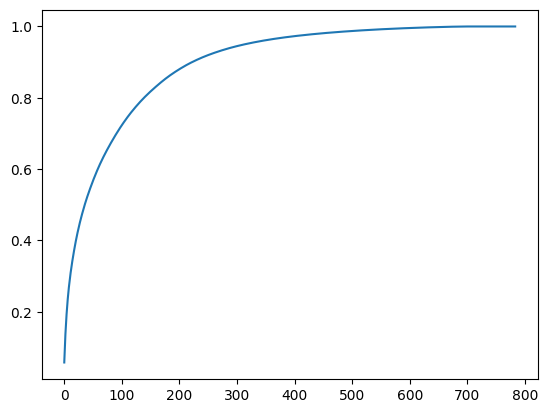

In [47]:
plt.plot(np.cumsum(pca_n.explained_variance_ratio_))